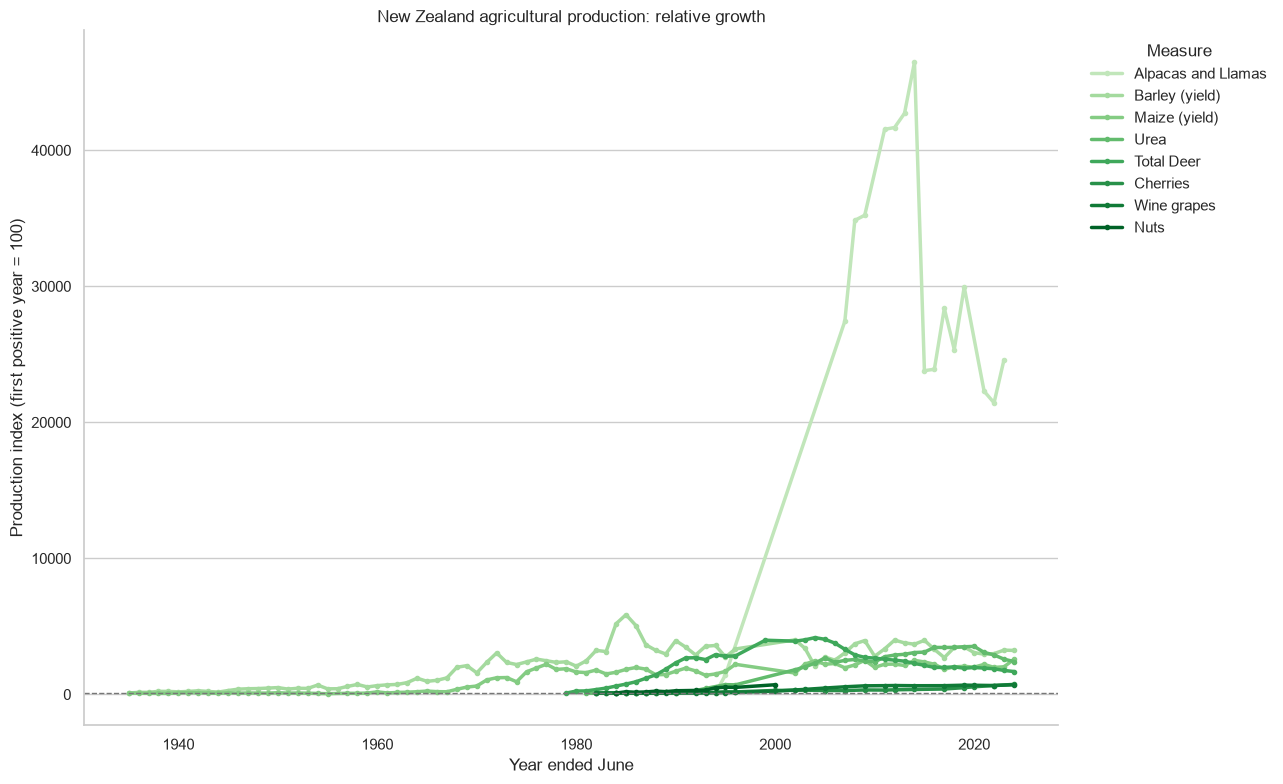

In [1]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Reuse the notebook's dataset if available; otherwise, download it.
if "dataset" not in globals():
    url = (
        "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
        "main/data/2026/2026-02-17/dataset.csv"
    )
    dataset = pd.read_csv(url)

df = dataset.copy()
df["year_ended_june"] = pd.to_numeric(df["year_ended_june"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df = df.dropna(subset=["year_ended_june", "measure", "value"])

# Index each measure to 100 at its first positive observation.
indexed = []
for measure, group in df.groupby("measure"):
    group = group.sort_values("year_ended_june")
    group = group[group["value"] > 0]

    if len(group) < 2:
        continue

    group = group.copy()
    group["index"] = group["value"] / group["value"].iloc[0] * 100
    indexed.append(group)

if not indexed:
    raise ValueError("No measures have enough positive observations to chart.")

trend = pd.concat(indexed, ignore_index=True)

# Select the eight measures with the greatest relative growth.
growth = (
    trend.groupby("measure")
    .apply(lambda group: group["index"].iloc[-1] / group["index"].iloc[0])
    .sort_values(ascending=False)
)
top_measures = growth.head(8).index
plot_data = trend[trend["measure"].isin(top_measures)]

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(13, 8))
greens = sns.color_palette("Greens", n_colors=len(top_measures) + 2)[2:]

for color, measure in zip(greens, top_measures):
    series = plot_data[plot_data["measure"] == measure].sort_values("year_ended_june")
    ax.plot(
        series["year_ended_june"],
        series["index"],
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=3,
        label=measure,
    )

ax.axhline(100, color="#777777", linestyle="--", linewidth=1)
ax.set(
    title="New Zealand agricultural production: relative growth",
    xlabel="Year ended June",
    ylabel="Production index (first positive year = 100)",
)
ax.legend(title="Measure", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax.grid(axis="x", visible=False)
sns.despine()
fig.tight_layout()
plt.show()